In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

Mutual fund schemes showed a consistent NAV growth trend between 2022 and 2025.


In [3]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")


fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (2022-2026)"
)

fig.show()

SBI Mutual Fund maintained one of the highest AUM levels among all fund houses

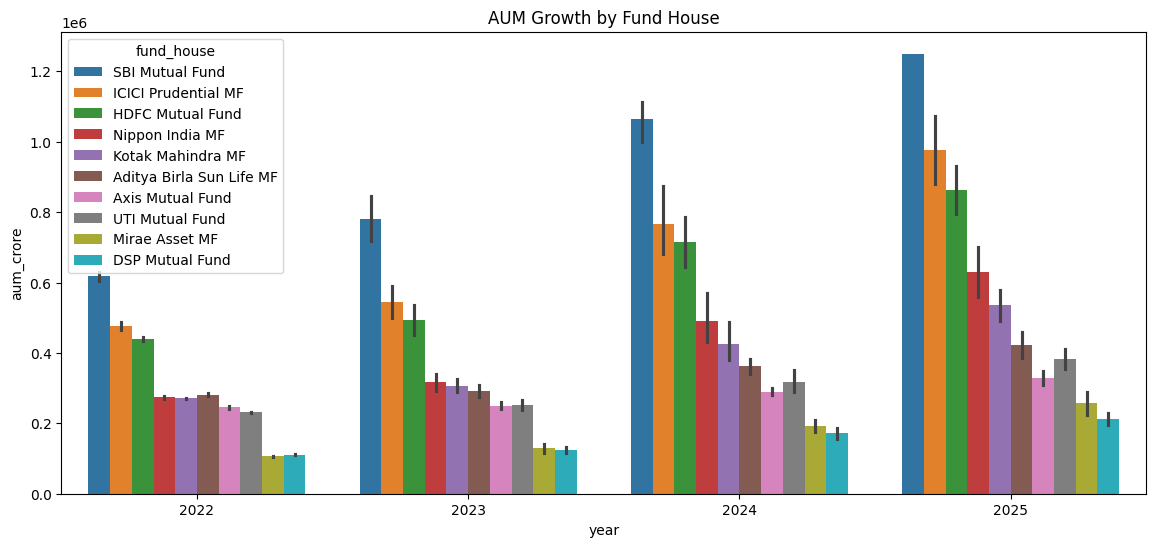

In [5]:
aum = pd.read_csv("../data/processed/aum_by_fund_house_clean.csv")

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.show()

In [7]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows - Copy.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

fig.show()

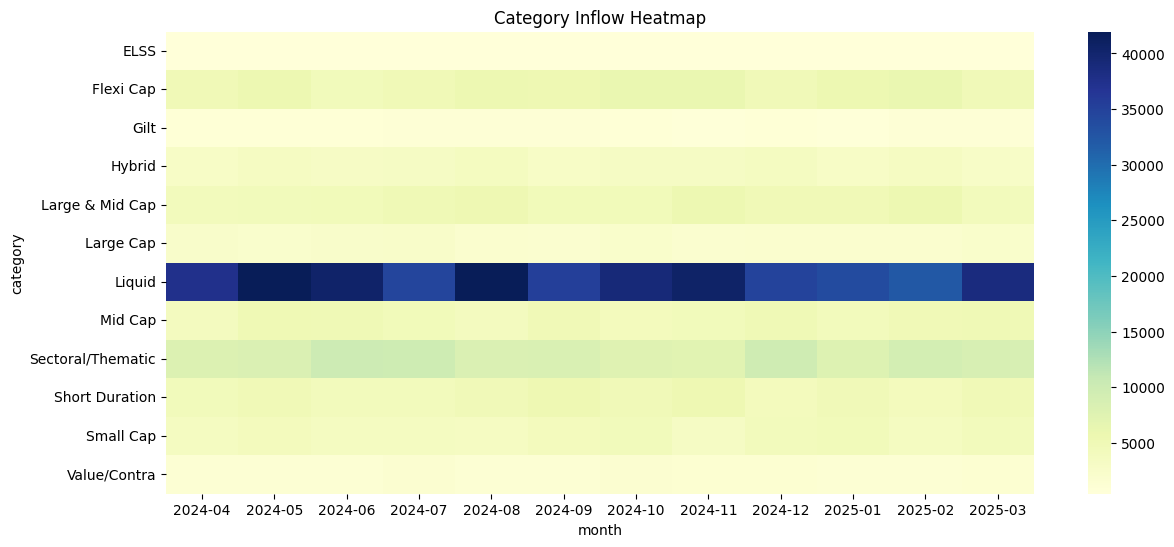

In [8]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.show()

The 26-35 age group contributed the largest share of mutual fund investments.

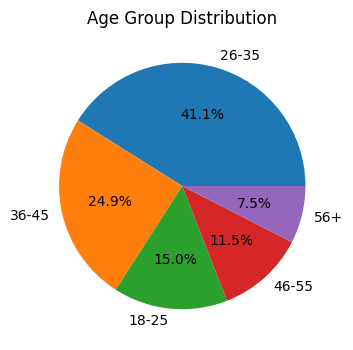

In [10]:
investor = pd.read_csv("../data/processed/investor_transactions_clean.csv")

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(4,4)
)

plt.title("Age Group Distribution")
plt.ylabel("")
plt.show()

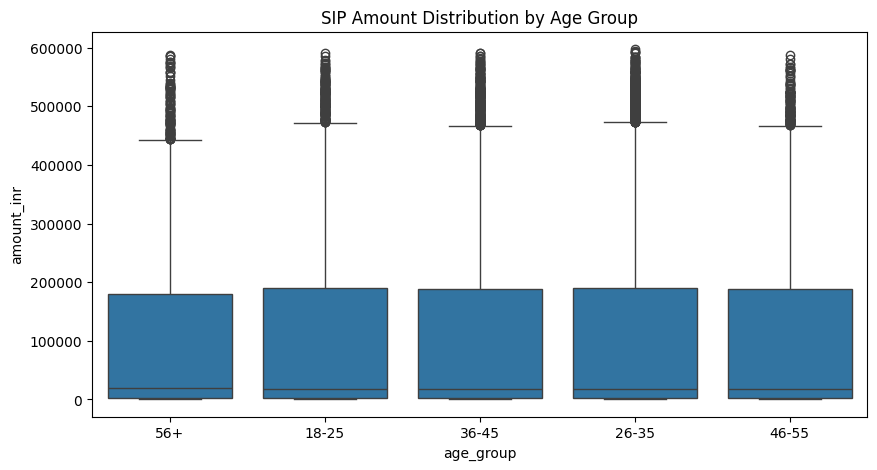

In [11]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.show()

Male investors represented a higher proportion of transactions than female investors.


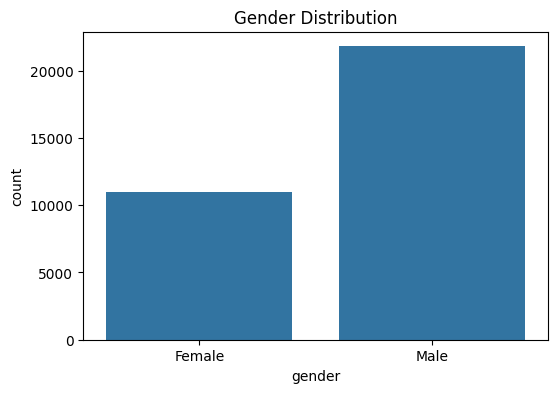

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=investor,
    x="gender"
)

plt.title("Gender Distribution")
plt.show()

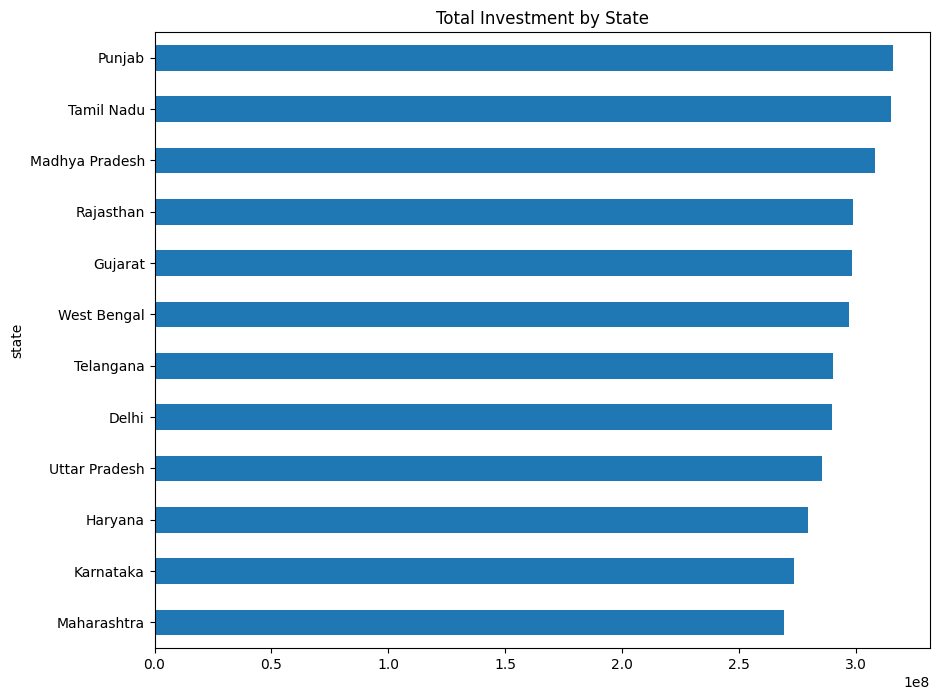

In [13]:
state_data = investor.groupby(
    "state"
)["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

state_data.plot(kind="barh")

plt.title("Total Investment by State")
plt.show()

Investors from T30 cities account for approximately 66% of total transactions.

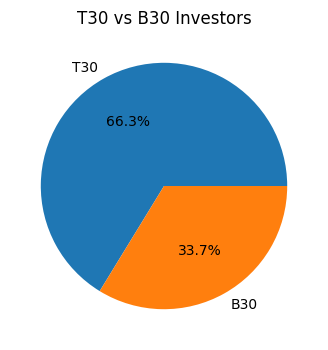

In [15]:
investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(4,4)
)

plt.title("T30 vs B30 Investors")
plt.ylabel("")
plt.show()

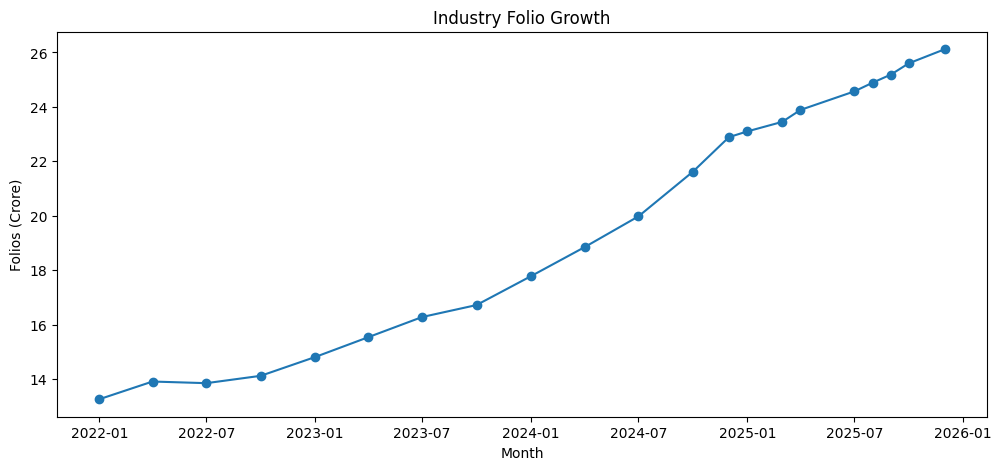

In [16]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.show()

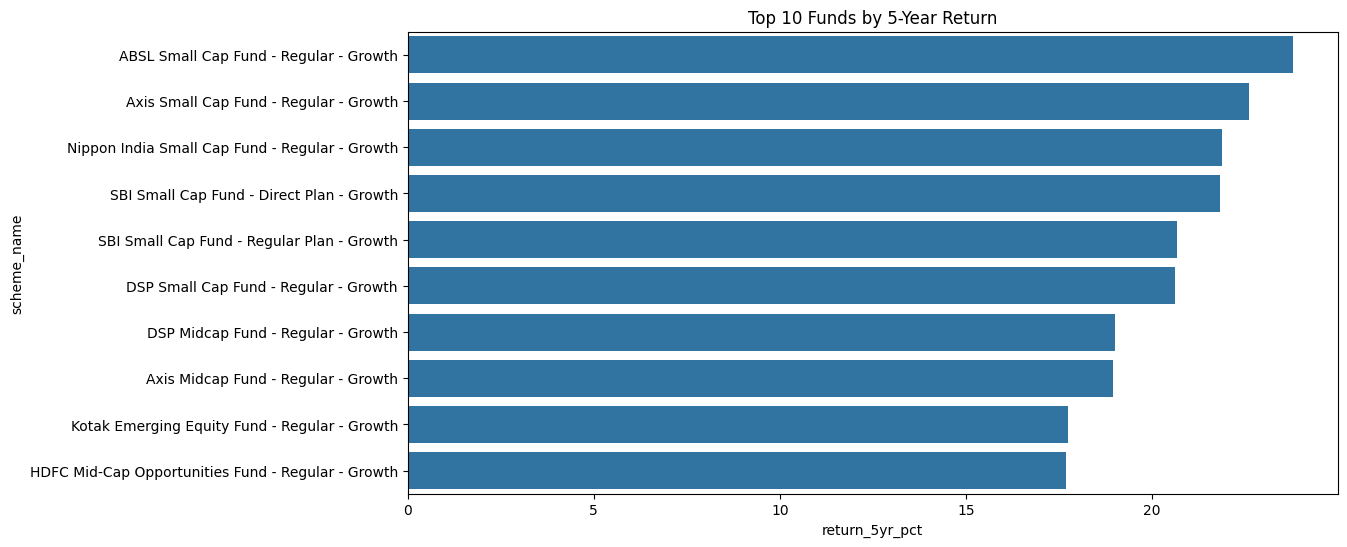

In [17]:
perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")

top10 = perf.nlargest(
    10,
    "return_5yr_pct"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.show()

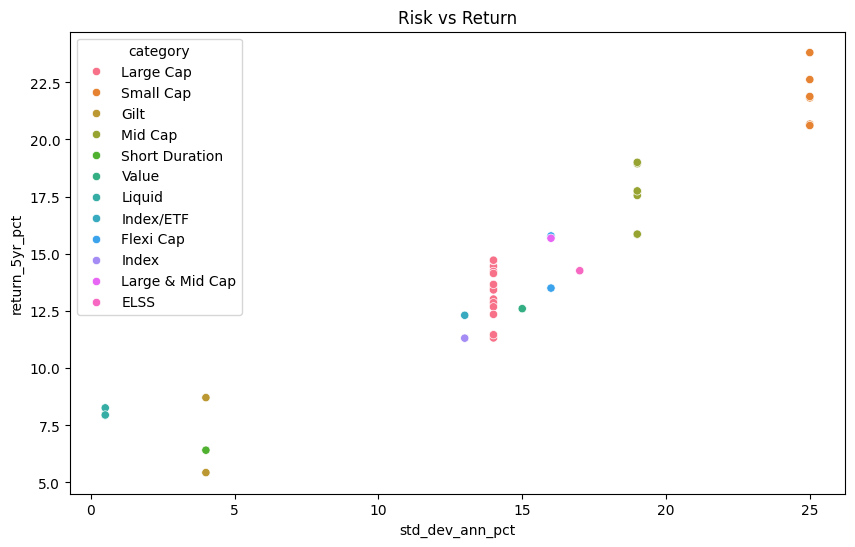

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=perf,
    x="std_dev_ann_pct",
    y="return_5yr_pct",
    hue="category"
)

plt.title("Risk vs Return")
plt.show()

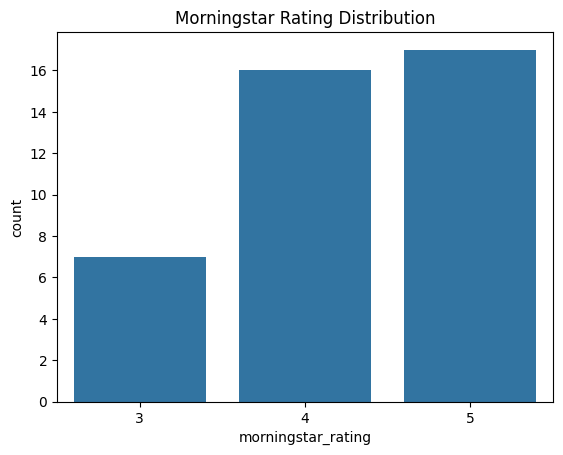

In [19]:
sns.countplot(
    data=perf,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")
plt.show()

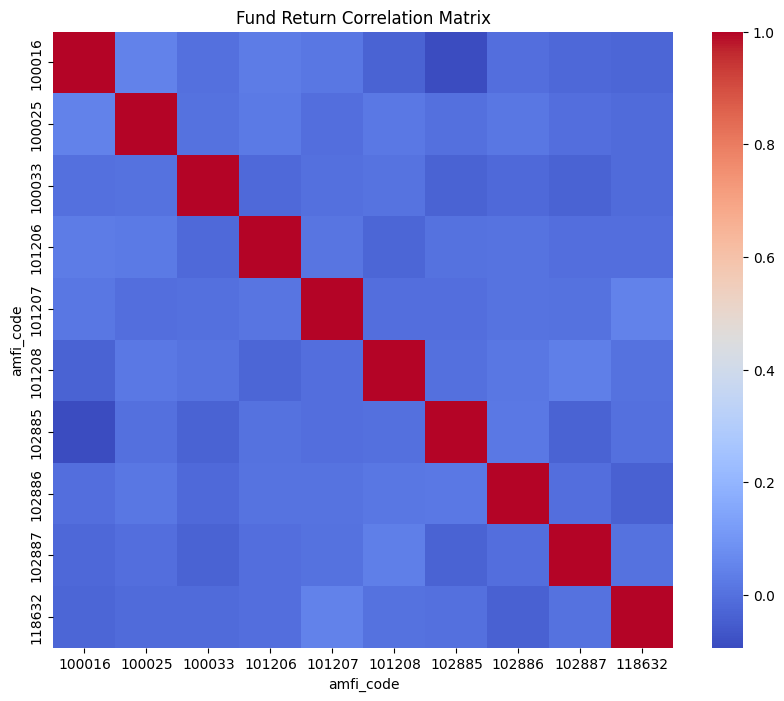

In [20]:
top_funds = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]

pivot = top_funds.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")
plt.show()

Pharma, IT, and Banking sectors accounted for a substantial portion of portfolio allocations.

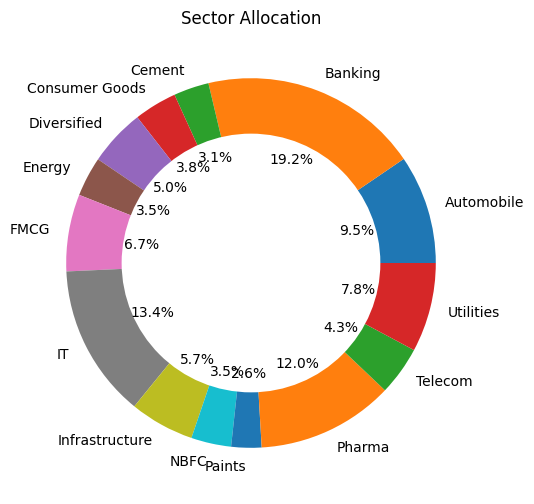

In [23]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

sector = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(6,6))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre)

plt.title("Sector Allocation")
plt.show()

top 10 holdinngs performed nice

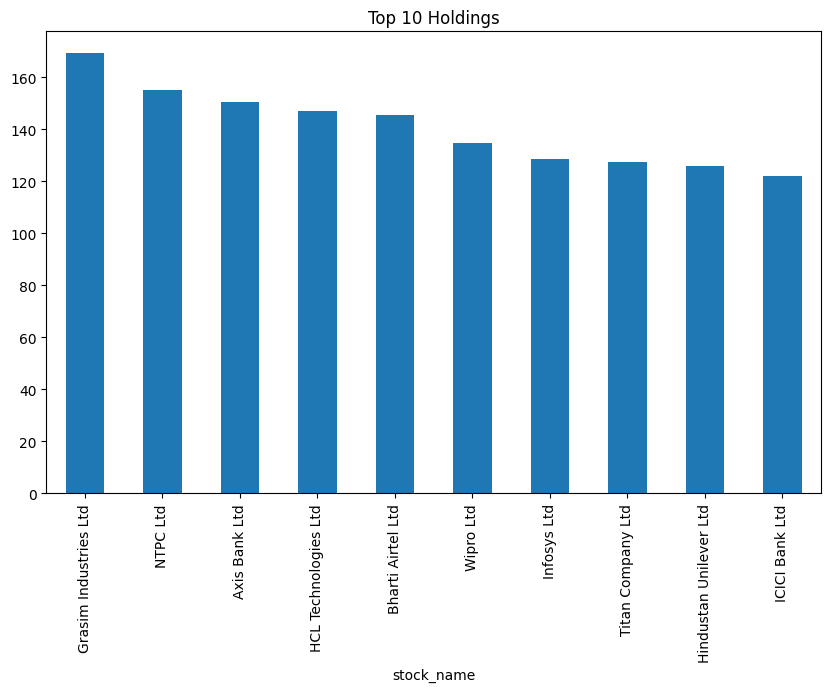

In [24]:
top_holdings = portfolio.groupby(
    "stock_name"
)["weight_pct"].sum().nlargest(10)

plt.figure(figsize=(10,6))

top_holdings.plot(kind="bar")

plt.title("Top 10 Holdings")
plt.show()